In [1]:
import pandas as pd
import numpy as np
import os
from tqdm import tqdm
import math
import re

import sys
# sys.path.append('../../../')
# from mount_drive import mount_s_drive

In [2]:
import pandas as pd
import os
import sys
dir1 = os.path.abspath(os.path.join(os.getcwd(), '../../analysisFunctions'))
sys.path.insert(0, dir1)
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from scipy import stats
import statsmodels.api as sm
from statsmodels.formula.api import ols
from statsmodels.stats.multicomp import pairwise_tukeyhsd
from sklearn.preprocessing import StandardScaler, OneHotEncoder
from sklearn.compose import ColumnTransformer
from sklearn.metrics import accuracy_score, roc_auc_score, make_scorer, auc, roc_curve
from sklearn.model_selection import train_test_split, StratifiedKFold, cross_val_score, GridSearchCV
from xgboost import XGBClassifier, XGBRegressor, plot_tree, plot_importance, to_graphviz
from sklearn.pipeline import Pipeline
from sklearn.neighbors import KNeighborsClassifier
from sklearn.linear_model import LogisticRegression
from sklearn.impute import SimpleImputer, KNNImputer
from sklearn.tree import DecisionTreeClassifier, export_graphviz
from sklearn.ensemble import RandomForestClassifier, RandomForestRegressor
from graphviz import Source
from sklearn import tree
from sklearn.svm import SVC, LinearSVC, SVR
import re
from machine_learning import *
from sklearn.neighbors import KNeighborsRegressor
from sklearn.metrics import r2_score, mean_absolute_error, mean_squared_error
import statsmodels.api as sm
import statsmodels.formula.api as smf
from scipy.stats import chi2
from sklearn.cluster import KMeans,AgglomerativeClustering, SpectralClustering, MeanShift, DBSCAN 
from scipy.cluster.hierarchy import dendrogram, linkage
import warnings
warnings.filterwarnings('ignore', category=DeprecationWarning)
import random
from stepmix.stepmix import StepMix
from sklearn.metrics import silhouette_score
from mlxtend.feature_selection import SequentialFeatureSelector as SFS
from sklearn.impute import KNNImputer
from sklearn.feature_selection import VarianceThreshold

from MIMICUtil import *

In [104]:
columns = [
    'chart_first_height',
    'chart_first_height_(cm)',
    'chart_first_admission_weight_(kg)',
    'chart_first_admission_weight_(lbs.)',
    'chart_first_daily_weight',

    'chart_first_heart_rate',
    'chart_first_o2_saturation_pulseoxymetry',
    'chart_first_temperature_celsius',
    'chart_first_respiratory_rate',
    'chart_first_inspired_o2_fraction',

    'chart_first_non_invasive_blood_pressure_systolic',
    'chart_first_non_invasive_blood_pressure_diastolic',
    'chart_first_non_invasive_blood_pressure_mean',
    'chart_first_art_bp_systolic',
    'chart_first_art_bp_diastolic',
    'chart_first_art_bp_mean',
    'chart_first_arterial_blood_pressure_systolic',
    'chart_first_arterial_blood_pressure_diastolic',
    'chart_first_arterial_blood_pressure_mean',

    'chart_first_ph_(arterial)',
    'chart_first_arterial_o2_pressure',
    'chart_first_arterial_co2_pressure',
    'chart_first_tco2_(calc)_arterial',
    'chart_first_arterial_base_excess',
    'chart_first_lactic_acid',

    'chart_first_qtc',

    'chart_first_wbc',
    'chart_first_hemoglobin',
    'chart_first_hematocrit_(serum)',

    'chart_first_sodium_(serum)',
    'chart_first_chloride_(serum)',
    'chart_first_bun',
    'chart_first_creatinine_(serum)',
    'chart_first_glucose_(serum)',
    'chart_first_calcium_non-ionized',
    'chart_first_ionized_calcium',
    'chart_first_magnesium',
    'chart_first_phosphorous',

    'chart_first_total_bilirubin',
    'chart_first_direct_bilirubin',
    'chart_first_total_protein',
    'chart_first_ck_(cpk)',
    'chart_first_ck-mb_fraction_(%)',
    'chart_first_ldh',
    'chart_first_triglyceride',
    'chart_first_cholesterol',
    'chart_first_hdl',
    'chart_first_ldl_calculated',

    'chart_first_d-dimer',
    'lab_first_inr',
    'lab_first_prothrombin_time',
    'lab_first_ptt',
    'lab_first_fibrinogen',
    'lab_first_c_reactive_protein_(crp)',
    'lab_first_troponin-t',
    'lab_first_specific_gravity_(urine)',
    'first_mGCS',

    'long_title_atrial_fibrillation',
       'long_title_chronic_atrial_fibrillation',
       'long_title_chronic_atrial_fibrillation,_unspecified',
       'long_title_other_persistent_atrial_fibrillation',
       'long_title_paroxysmal_atrial_fibrillation',
       'long_title_persistent_atrial_fibrillation',
       'long_title_unspecified_atrial_fibrillation',
       'long_title_ventricular_fibrillation'
    'other_underlying_condition',
    'underlying_cardiac_condition',
    'following_other_sur',
    'following_cardiac_sur',
]


In [105]:
[x for x in myPredictorsDf.columns if 'asy' in x.lower()]

['chart_cpot-vocalization_(cpotb)_Crying out, sobbing OR Fighting vent/asynchrony, frequent alarms',
 'chart_temporary_pacemaker_mode_Ventricular Asychronous']

In [106]:
import pandas as pd
from sklearn.model_selection import train_test_split
import numpy as np
# death_at_disch hypothermia 
def getTrainTestFunctions(aPredictedColumn = 'LastMGCSPositive', aTreatmentColumn = 'hypothermia', aTestSize = 0.3, aTreatmentSplit = False, aDropColumns = [], aSkipTemp = True):
    myPredictorsDf = pd.read_csv('MIMIC_Predictors.csv')

    # top_corr = pd.read_csv('top_correlations.csv')
    # columns_to_drop = top_corr[top_corr['hypothermia'].abs() > 0.7]['Unnamed: 0'].tolist()
    columns_to_drop = []
    # Preprocessing
    myFilter = (myPredictorsDf['first_mGCS_time'] != myPredictorsDf['last_mGCS_time']) 
    myPredictorsDf.loc[myPredictorsDf['death_at_disch'] == 1, 'last_mGCS'] = 1
    myPredictorsDf.loc[myFilter, 'LastMGCSPositive'] = (myPredictorsDf.loc[myFilter, 'last_mGCS'].astype(float) == 6).astype(int)

    myBinaryColumns = myPredictorsDf.columns[myPredictorsDf.nunique() == 2] 
    myBinaryDf = myPredictorsDf[myBinaryColumns]
    myBinaryDf = myBinaryDf.select_dtypes(exclude=["object"])
    myLowColumns = myBinaryDf.columns[(myBinaryDf.sum() < 15)]
    myPredictorsDf.drop(columns=list(myLowColumns) + aDropColumns, inplace=True)

    myGcs15Fitler = (myPredictorsDf.first_mGCS != 6)

    if (aPredictedColumn == 'LastMGCSPositive'):
        myPredictorsDf = myPredictorsDf[myGcs15Fitler & myFilter & ~myPredictorsDf[aTreatmentColumn].isna()]
    else:
        myPredictorsDf = myPredictorsDf[myGcs15Fitler & ~myPredictorsDf[aPredictedColumn].isna() & ~myPredictorsDf[aTreatmentColumn].isna()]

    myColumns = []
    if (aSkipTemp):
        myColumns = [x for x in myPredictorsDf.columns if 'emp' in x or 'dx_' == x[0:3]]

    # Get output data
    myXValue = myPredictorsDf.drop(columns=columns_to_drop +  myColumns + [ 'last_mGCS_time', 'first_mGCS_time', 'LastMGCSPositive', 'last_mGCS', 'death_at_disch'])
    myXValue = myXValue
    myXValue = myXValue.select_dtypes(exclude=['object'])
    myYValue = myPredictorsDf[aPredictedColumn]
    myYValue = myYValue.astype(int)

    if (aTreatmentSplit):
        myXValue = myXValue.drop(columns=[aTreatmentColumn])
        X_train, X_test, T_train, T_test, y_train, y_test = train_test_split(myXValue, myPredictorsDf[aTreatmentColumn], myYValue, stratify=myPredictorsDf[[aPredictedColumn, aTreatmentColumn]], test_size=aTestSize)
        return myPredictorsDf, X_train, X_test, T_train, T_test, y_train, y_test
    else:
        X_train, X_test, y_train, y_test = train_test_split(myXValue, myYValue, stratify=myPredictorsDf[[aPredictedColumn, aTreatmentColumn]], test_size=aTestSize)
        return myPredictorsDf, X_train, X_test, y_train, y_test

In [107]:
from econml.dml import CausalForestDML, SparseLinearDML, LinearDML, DML
from econml.orf import DMLOrthoForest
from econml.dr import LinearDRLearner
myTreatment = 'hypothermia'
myTreatmentColumn = myTreatment
myPredicted = 'LastMGCSPositive'
myPredictorsDf, X_train_no_group, X_test_no_group, T_train, T_test, y_train, y_test =  \
                    getTrainTestFunctions(aPredictedColumn = myPredicted, 
                                            aTreatmentColumn = myTreatment, aTreatmentSplit = True, aSkipTemp = True, 
                                            aTestSize=.3) 
causal_forest = CausalForestDML(
    model_y= XGBClassifier(max_depth=3, n_estimators=50),  
    model_t= XGBClassifier(max_depth=2, n_estimators=20),    
    discrete_treatment=True,           
    discrete_outcome=True,
    verbose=2,
    n_jobs=-1
)

In [108]:
def getCovariatePreprocessor(aKeepColumns):
    return    ColumnTransformer(
            transformers=[
                ('keep', 'passthrough', aKeepColumns), 
            ],
            remainder = PCA(0.99)
        )

def getVariancePreprocessor(aKeepColumns):
    return    ColumnTransformer(
            transformers=[
                ('keep', 'passthrough', aKeepColumns), 
            ],
            remainder = VarianceThreshold(0.01)
        )
def getDefaultPipelineSteps(X_train):
    myNumericalColumns = X_train.columns[(X_train.nunique() > 5) & (X_train.dtypes != object)]
    myBinaryColumns = X_train.columns[X_train.nunique() == 2]
    myPreprocessor = getDefaultPreprocessor(aNumericalColumns=myNumericalColumns, aBinaryColumns=myBinaryColumns)
    myPreprocessor.set_output(transform="pandas")
    myImputer = KNNImputer(n_neighbors=50)
    myImputer.set_output(transform="pandas")
    myCovariates = getCovariatePreprocessor([])
    myCovariates.set_output(transform="pandas")
    myVariance = getVariancePreprocessor([])
    myVariance.set_output(transform="pandas")
    return [('preprocessor', myPreprocessor), ('imputer', myImputer)]

In [109]:
# X_train_no_group = X_train_no_group.loc[:, X_train_no_group.isnull().mean() < 0.9]
# X_test_no_group = X_test_no_group[X_train_no_group.columns]

columns_filter = np.unique([x for x in columns if x in X_train_no_group.columns])
X_train_no_group = X_train_no_group[columns_filter]
X_test_no_group = X_test_no_group[columns_filter]

In [110]:
# X_train_no_group = X_train_no_group

In [111]:
myPipeline = Pipeline(getDefaultPipelineSteps(X_train_no_group))

In [112]:
myNewXTrain = pd.DataFrame(myPipeline.fit_transform(X_train_no_group), columns = myPipeline.get_feature_names_out())
myNewXTest = pd.DataFrame(myPipeline.transform(X_test_no_group), columns = myPipeline.get_feature_names_out())


In [113]:
causal_forest.fit(y_train, T_train, X=myNewXTrain, cache_values=True)
print(causal_forest.score(y_train, T_train, X=myNewXTrain))

CATE_pred = causal_forest.effect(myNewXTrain)

print(f'Feature importances {causal_forest.feature_importances_}')

print("Predicted CATE for test data:", CATE_pred[:10])

0.07399573703766268
Feature importances [0.02024188 0.00971099 0.01556623 0.01845811 0.01105008 0.03336826
 0.00347806 0.03843142 0.04137524 0.01524377 0.01562268 0.03412865
 0.01374458 0.         0.01373134 0.04258003 0.00845676 0.06622453
 0.04317178 0.         0.02858901 0.03922737 0.01835547 0.00986399
 0.01307781 0.0278138  0.01605132 0.         0.02134145 0.03405111
 0.0132788  0.01394213 0.01344341 0.02906694 0.02520515 0.01115074
 0.01200401 0.01409183 0.02496954 0.         0.02869767 0.03343695
 0.00828603 0.02294267 0.03374515 0.00433677 0.03544519 0.
 0.         0.         0.         0.         0.         0.
 0.         0.         0.         0.         0.         0.
 0.00386855 0.         0.         0.         0.01913276 0.        ]
Predicted CATE for test data: [[-0.04710266]
 [ 0.00457144]
 [-0.01594589]
 [-0.03599671]
 [-0.02707381]
 [ 0.00605553]
 [ 0.04139793]
 [-0.05671389]
 [-0.06141339]
 [-0.01125028]]


[Parallel(n_jobs=-1)]: Using backend ThreadingBackend with 64 concurrent workers.
[Parallel(n_jobs=-1)]: Done  24 out of 100 | elapsed:    0.0s remaining:    0.1s
[Parallel(n_jobs=-1)]: Done  75 out of 100 | elapsed:    0.0s remaining:    0.0s
[Parallel(n_jobs=-1)]: Done 100 out of 100 | elapsed:    0.0s finished
[Parallel(n_jobs=-1)]: Using backend ThreadingBackend with 64 concurrent workers.
[Parallel(n_jobs=-1)]: Done  24 out of 100 | elapsed:    0.0s remaining:    0.1s
[Parallel(n_jobs=-1)]: Done  75 out of 100 | elapsed:    0.0s remaining:    0.0s
[Parallel(n_jobs=-1)]: Done 100 out of 100 | elapsed:    0.0s finished
[Parallel(n_jobs=64)]: Using backend ThreadingBackend with 64 concurrent workers.
[Parallel(n_jobs=64)]: Done  24 out of 100 | elapsed:    0.0s remaining:    0.0s
[Parallel(n_jobs=64)]: Done  75 out of 100 | elapsed:    0.0s remaining:    0.0s
[Parallel(n_jobs=64)]: Done 100 out of 100 | elapsed:    0.0s finished
[Parallel(n_jobs=64)]: Using backend ThreadingBackend w

In [114]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

def _combine_x_w(X=None, W=None):
    """
    Reconstruct the design matrix used by econml first-stage nuisance models.
    """
    if X is None and W is None:
        raise ValueError("At least one of X or W must be provided.")
    if X is None:
        return np.asarray(W)
    if W is None:
        return np.asarray(X)
    return np.hstack([np.asarray(X), np.asarray(W)])


def get_cf_propensity_scores(cf, X=None, W=None):
    """
    Estimate propensity scores from a fitted econml CausalForestDML object
    by averaging predictions from the fitted first-stage treatment models.

    Parameters
    ----------
    cf : fitted econml.dml.CausalForestDML
    X : array-like or DataFrame, optional
        Heterogeneity features used in fit.
    W : array-like or DataFrame, optional
        Controls used in fit.

    Returns
    -------
    p_hat : np.ndarray, shape (n_samples,)
        Estimated propensity score P(T=1 | X, W).
    """
    XW = _combine_x_w(X, W)

    # econml stores first-stage treatment models in a nested list:
    # outer level = MC iterations, inner level = cross-fit folds
    models_t = cf.models_t

    if models_t is None or len(models_t) == 0:
        raise ValueError("No fitted treatment nuisance models found in cf.models_t")

    preds = []

    for mc_models in models_t:
        for mdl in mc_models:
            if hasattr(mdl, "predict_proba"):
                p = mdl.predict_proba(XW)
                # binary treatment: take probability of class 1
                if p.ndim == 2:
                    if p.shape[1] == 2:
                        p = p[:, 1]
                    elif p.shape[1] == 1:
                        p = p[:, 0]
                    else:
                        raise ValueError(
                            f"Unexpected predict_proba output shape {p.shape} for binary treatment."
                        )
                preds.append(np.asarray(p).reshape(-1))
            elif hasattr(mdl, "predict"):
                # fallback, though for binary discrete treatment predict_proba is preferred
                p = mdl.predict(XW)
                preds.append(np.asarray(p).reshape(-1))
            else:
                raise ValueError(
                    f"Treatment nuisance model {type(mdl)} has neither predict_proba nor predict."
                )

    if len(preds) == 0:
        raise ValueError("Could not extract any propensity predictions from cf.models_t")

    p_hat = np.mean(np.vstack(preds), axis=0)

    # guard against exact 0/1 values
    eps = 1e-6
    p_hat = np.clip(p_hat, eps, 1 - eps)

    return p_hat
def positivity_flag(df, low=0.05, high=0.95, frac_threshold=0.05):
    """
    Flag severe positivity issues if too many subjects lie near 0 or 1.
    """
    p = df["propensity"].values
    frac_extreme = np.mean((p < low) | (p > high))

    if frac_extreme >= frac_threshold:
        return {
            "severe_flag": True,
            "frac_extreme": frac_extreme,
            "message": f"Potential positivity concern: {frac_extreme:.1%} of scores are <{low} or >{high}."
        }
    else:
        return {
            "severe_flag": False,
            "frac_extreme": frac_extreme,
            "message": f"No major positivity concern by this rule: {frac_extreme:.1%} extreme scores."
        }
def make_propensity_df(cf, T, X=None, W=None, dataset_name="dataset"):
    """
    Create a dataframe with observed treatment and estimated propensity score.
    """
    p_hat = get_cf_propensity_scores(cf, X=X, W=W)

    df = pd.DataFrame({
        "dataset": dataset_name,
        "T": np.asarray(T).astype(int).reshape(-1),
        "propensity": p_hat
    })

    return df
def plot_propensity_overlap(df, ax=None, bins=30, title=None):
    """
    Overlap histogram for treated vs untreated groups.
    """
    if ax is None:
        fig, ax = plt.subplots(figsize=(6, 4))

    treated = df.loc[df["T"] == 1, "propensity"]
    control = df.loc[df["T"] == 0, "propensity"]

    ax.hist(control, bins=bins, alpha=0.6, density=True, label="No TTM")
    ax.hist(treated, bins=bins, alpha=0.6, density=True, label="TTM")

    ax.set_xlabel("Estimated propensity score")
    ax.set_ylabel("Density")
    ax.set_xlim(0, 1)
    ax.legend()
    ax.set_title(title or df["dataset"].iloc[0])

    return ax
def run_propensity_diagnostics(cf, T, X=None, W=None, dataset_name="dataset", bins=30):
    df = make_propensity_df(cf, T=T, X=X, W=W, dataset_name=dataset_name)
    summary = propensity_summary(df)
    flag = positivity_flag(df)

    fig, ax = plt.subplots(figsize=(6, 4))
    plot_propensity_overlap(df, ax=ax, bins=bins, title=dataset_name)
    plt.tight_layout()

    return df, summary, flag, fig
def propensity_summary(df):
    """
    Summarize overlap / positivity diagnostics.
    """
    out = []

    for tval, group_name in [(0, "No TTM"), (1, "TTM")]:
        s = df.loc[df["T"] == tval, "propensity"]

        out.append({
            "group": group_name,
            "n": len(s),
            "min": s.min(),
            "p01": np.quantile(s, 0.01),
            "p05": np.quantile(s, 0.05),
            "median": s.median(),
            "p95": np.quantile(s, 0.95),
            "p99": np.quantile(s, 0.99),
            "max": s.max(),
            "prop_<0.05": np.mean(s < 0.05),
            "prop_>0.95": np.mean(s > 0.95),
            "prop_<0.10": np.mean(s < 0.10),
            "prop_>0.90": np.mean(s > 0.90),
        })

    return pd.DataFrame(out)

In [115]:
import numpy as np
import pandas as pd
import statsmodels.api as sm
from scipy.stats import chi2


def simulate_dataset_hte(
    n,
    treat_prev,
    subgroup_prev,
    baseline_risk,
    abs_treatment_effect=0.10,
    rng=None
):
    """
    Simulate binary outcomes with HTE present only in a latent subgroup.

    Parameters
    ----------
    n : int
        Sample size.
    treat_prev : float
        Treatment prevalence P(T=1).
    subgroup_prev : float
        Responsive subgroup prevalence P(G=1).
    baseline_risk : float
        Baseline outcome probability for untreated, non-subgroup patients.
    abs_treatment_effect : float
        Absolute treatment effect applied only within subgroup.
        Positive means benefit for a favorable outcome.
    rng : np.random.Generator or None

    Returns
    -------
    df : pd.DataFrame
        Simulated data with columns T, G, cate_score, Y
    """
    if rng is None:
        rng = np.random.default_rng()

    # Treatment assignment
    T = rng.binomial(1, treat_prev, size=n)

    # Latent subgroup that benefits
    G = rng.binomial(1, subgroup_prev, size=n)

    # True individual treatment effect:
    # only subgroup members benefit
    true_tau = abs_treatment_effect * G

    # Outcome probability
    # Here outcome is assumed favorable, so treatment increases probability
    p = baseline_risk + T * true_tau

    # keep probabilities in valid range
    p = np.clip(p, 1e-6, 1 - 1e-6)

    # Binary outcome
    Y = rng.binomial(1, p, size=n)

    # Oracle "CATE score"
    cate_score = true_tau

    return pd.DataFrame({
        "T": T,
        "G": G,
        "cate_score": cate_score,
        "Y": Y
    })

def lr_test_interaction(df):
    """
    Likelihood ratio test comparing:
      reduced: Y ~ T + cate_score
      full:    Y ~ T + cate_score + T:cate_score
    """
    X_reduced = pd.DataFrame({
        "const": 1.0,
        "T": df["T"],
        "cate_score": df["cate_score"]
    })

    X_full = pd.DataFrame({
        "const": 1.0,
        "T": df["T"],
        "cate_score": df["cate_score"],
        "interaction": df["T"] * df["cate_score"]
    })

    try:
        m0 = sm.Logit(df["Y"], X_reduced).fit(disp=False)
        m1 = sm.Logit(df["Y"], X_full).fit(disp=False)

        lr_stat = 2 * (m1.llf - m0.llf)
        df_diff = X_full.shape[1] - X_reduced.shape[1]
        pval = chi2.sf(lr_stat, df_diff)

        return {
            "lr_stat": lr_stat,
            "pval": pval,
            "converged": True
        }
    except Exception:
        return {
            "lr_stat": np.nan,
            "pval": np.nan,
            "converged": False
        }
def estimate_power_for_scenario(
    n,
    treat_prev,
    subgroup_prev,
    baseline_risk,
    abs_treatment_effect=0.10,
    n_sims=1000,
    alpha=0.05,
    seed=42
):
    rng = np.random.default_rng(seed)

    pvals = []
    n_fail = 0

    for _ in range(n_sims):
        df = simulate_dataset_hte(
            n=n,
            treat_prev=treat_prev,
            subgroup_prev=subgroup_prev,
            baseline_risk=baseline_risk,
            abs_treatment_effect=abs_treatment_effect,
            rng=rng
        )
        res = lr_test_interaction(df)
        if res["converged"] and np.isfinite(res["pval"]):
            pvals.append(res["pval"])
        else:
            n_fail += 1

    pvals = np.array(pvals)
    power = np.mean(pvals < alpha) if len(pvals) > 0 else np.nan

    return {
        "n": n,
        "treat_prev": treat_prev,
        "subgroup_prev": subgroup_prev,
        "baseline_risk": baseline_risk,
        "abs_treatment_effect": abs_treatment_effect,
        "n_sims": n_sims,
        "n_successful_fits": len(pvals),
        "n_failed_fits": n_fail,
        "power": power
    }
Y_all = np.concatenate([y_train, y_test])
baseline_risk = Y_all[T_all == 0].mean()
dataset_specs = {
    "eICU": {"n": T_all.shape[0], "treat_prev": T_all.mean(), "baseline_risk": 1-baseline_risk},
}

/home/mbranda1/.local/lib/python3.11/site-packages/statsmodels/base/model.py:607: ConvergenceWarning: Maximum Likelihood optimization failed to converge. Check mle_retvals
  warnings.warn("Maximum Likelihood optimization failed to "
/home/mbranda1/.local/lib/python3.11/site-packages/statsmodels/base/model.py:607: ConvergenceWarning: Maximum Likelihood optimization failed to converge. Check mle_retvals
  warnings.warn("Maximum Likelihood optimization failed to "


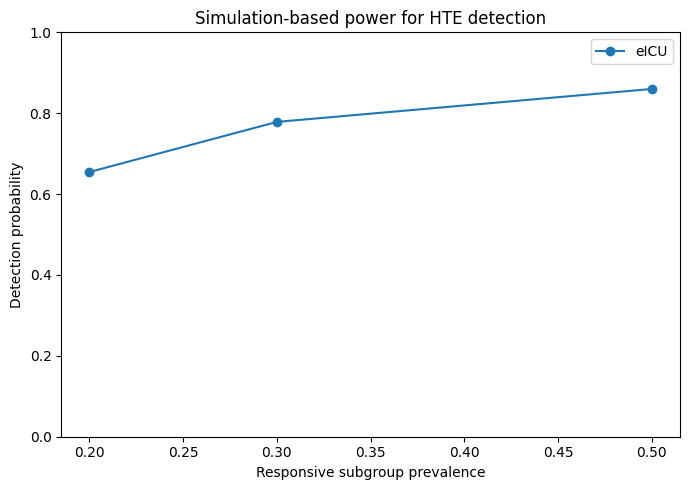

In [116]:
results = []

for ds, spec in dataset_specs.items():
    for subgroup_prev in [0.20, 0.30, 0.50]:
        out = estimate_power_for_scenario(
            n=spec["n"],
            treat_prev=spec["treat_prev"],
            subgroup_prev=subgroup_prev,
            baseline_risk=spec["baseline_risk"],
            abs_treatment_effect=0.20,
            n_sims=2000,
            alpha=0.05,
            seed=42
        )
        out["dataset"] = ds
        results.append(out)

power_table = pd.DataFrame(results)
power_table = power_table[[
    "dataset", "n", "treat_prev", "subgroup_prev",
    "baseline_risk", "abs_treatment_effect",
    "n_sims", "power", "n_failed_fits"
]]
power_table
import matplotlib.pyplot as plt

def plot_power_curves(power_table):
    fig, ax = plt.subplots(figsize=(7, 5))

    for ds, subdf in power_table.groupby("dataset"):
        subdf = subdf.sort_values("subgroup_prev")
        ax.plot(
            subdf["subgroup_prev"],
            subdf["power"],
            marker="o",
            label=ds
        )

    ax.set_xlabel("Responsive subgroup prevalence")
    ax.set_ylabel("Detection probability")
    ax.set_title("Simulation-based power for HTE detection")
    ax.set_ylim(0, 1)
    ax.legend()
    plt.tight_layout()
    plt.show()

plot_power_curves(power_table)

In [117]:
power_table

,dataset,n,treat_prev,subgroup_prev,baseline_risk,abs_treatment_effect,n_sims,power,n_failed_fits
0,eICU,560,0.5,0.2,0.667857,0.2,2000,0.6545,0
1,eICU,560,0.5,0.3,0.667857,0.2,2000,0.7785,0
2,eICU,560,0.5,0.5,0.667857,0.2,2000,0.8600,0


    group    n       min       p01       p05    median       p95       p99  \
0  No TTM  280  0.040209  0.084578  0.110236  0.352476  0.660027  0.767154   
1     TTM  280  0.183776  0.223970  0.362897  0.651773  0.839289  0.878887   

        max  prop_<0.05  prop_>0.95  prop_<0.10  prop_>0.90  
0  0.796042    0.003571         0.0    0.032143    0.000000  
1  0.932056    0.000000         0.0    0.000000    0.007143  
{'severe_flag': False, 'frac_extreme': np.float64(0.0017857142857142857), 'message': 'No major positivity concern by this rule: 0.2% extreme scores.'}


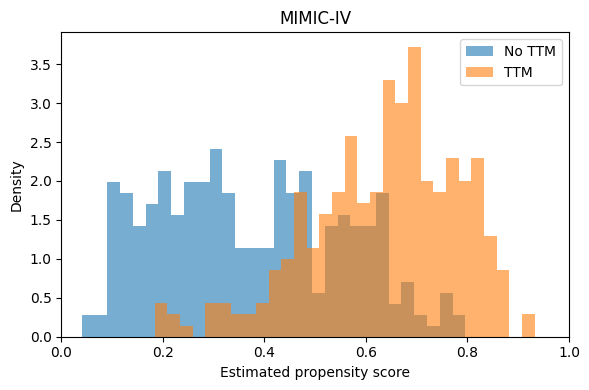

In [118]:
T_all = np.concatenate([T_train, T_test])
X_all = np.concatenate([myNewXTrain, myNewXTest])
ps_eicu, sum_eicu, flag_eicu, fig_eicu = run_propensity_diagnostics(
    causal_forest, T=T_all, X=X_all, W=None, dataset_name="MIMIC-IV"
)
print(sum_eicu)
print(flag_eicu)

In [119]:
print("eICU:", positivity_flag(ps_eicu, 0.6, 0.8))


eICU: {'severe_flag': True, 'frac_extreme': np.float64(0.6803571428571429), 'message': 'Potential positivity concern: 68.0% of scores are <0.6 or >0.8.'}


In [120]:
causal_forest.summary()

Population summary of CATE predictions on Training Data


[Parallel(n_jobs=64)]: Using backend ThreadingBackend with 64 concurrent workers.
[Parallel(n_jobs=64)]: Done  24 out of 100 | elapsed:    0.2s remaining:    0.5s
[Parallel(n_jobs=64)]: Done  75 out of 100 | elapsed:    0.2s remaining:    0.1s
[Parallel(n_jobs=64)]: Done 100 out of 100 | elapsed:    0.2s finished
[Parallel(n_jobs=25)]: Using backend ThreadingBackend with 25 concurrent workers.
[Parallel(n_jobs=25)]: Done   2 out of  25 | elapsed:    0.0s remaining:    0.1s
[Parallel(n_jobs=25)]: Done  15 out of  25 | elapsed:    0.0s remaining:    0.0s
[Parallel(n_jobs=25)]: Done  25 out of  25 | elapsed:    0.0s finished


<class 'econml.utilities.Summary'>
"""
               Uncertainty of Mean Point Estimate              
===============================================================
mean_point stderr_mean zstat pvalue ci_mean_lower ci_mean_upper
---------------------------------------------------------------
     0.001       0.105 0.012  0.991        -0.205         0.207
      Distribution of Point Estimate     
=========================================
std_point pct_point_lower pct_point_upper
-----------------------------------------
    0.049          -0.097           0.103
     Total Variance of Point Estimate     
==========================================
stderr_point ci_point_lower ci_point_upper
------------------------------------------
       0.116          -0.23          0.231
       Doubly Robust ATE on Training Data Results       
========================================================
    point_estimate stderr zstat pvalue ci_lower ci_upper
--------------------------------------------------------
ATE          0.037  0.097 0.381  0.703   -0.153    0.227
    Doubly Robust ATT(T=0) on Training Data Results     
========================================================
    point_estimate stderr zstat pvalue ci_lower ci_upper
--------------------------------------------------------
ATT         -0.106  0.166 -0.64  0.522   -0.431    0.219
    Doubly Robust ATT(T=1) on Training Data Results     
========================================================
    point_estimate stderr zstat pvalue ci_lower ci_upper
--------------------------------------------------------
ATT           0.18    0.1 1.798  0.072   -0.016    0.376
--------------------------------------------------------

Note: The stderr_mean is a conservative upper bound.
"""

Optimization terminated successfully.
         Current function value: 0.630912
         Iterations 5
Optimization terminated successfully.
         Current function value: 0.627396
         Iterations 5
Likelihood ratio of test results:
Chi square statistic: 2.7570637208131643
p-value: 0.09682580376155078
Degress of freedom: 1.0
No interaction                            Logit Regression Results                           
Dep. Variable:       LastMGCSPositive   No. Observations:                  392
Model:                          Logit   Df Residuals:                      389
Method:                           MLE   Df Model:                            2
Date:                Sun, 29 Mar 2026   Pseudo R-squ.:                0.001238
Time:                        13:31:35   Log-Likelihood:                -247.32
converged:                       True   LL-Null:                       -247.62
Covariance Type:            nonrobust   LLR p-value:                    0.7360
                     

[Parallel(n_jobs=64)]: Using backend ThreadingBackend with 64 concurrent workers.
[Parallel(n_jobs=64)]: Done  24 out of 100 | elapsed:    0.0s remaining:    0.0s
[Parallel(n_jobs=64)]: Done  75 out of 100 | elapsed:    0.0s remaining:    0.0s
[Parallel(n_jobs=64)]: Done 100 out of 100 | elapsed:    0.0s finished


np.float64(0.09682580376155078)

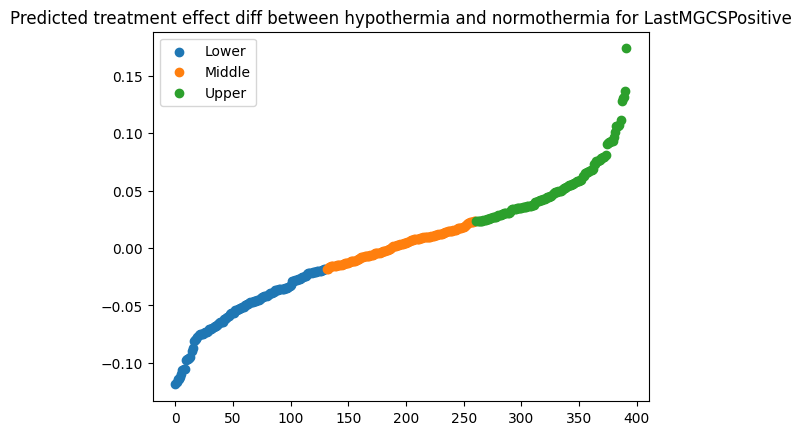

In [121]:
# myNewXTrain = pd.DataFrame(myPipeline.transform(X_train_no_group), columns = myPipeline.get_feature_names_out())
CATE_pred = causal_forest.effect(myNewXTrain)

myNewDf = pd.DataFrame()
myNewDf['predicted_effect'] = CATE_pred[:, 0]
lower_third, upper_third, _ = getPredictedThirds(myNewDf)
plotPredictedTreatmentEffect(myNewDf, myPredicted)
# myNewDf['predicted_effect_group'] = (myNewDf['predicted_effect'] > 0).astype(str)

X_train_new = X_train_no_group.copy().reset_index()
X_train_new[myTreatment] = T_train.reset_index()[myTreatment]
y_train_df = pd.DataFrame()
y_train_df[myPredicted] = y_train.reset_index()[myPredicted]
getTreatmentEffectDiffDataFrame(X_train_new, y_train_df, myNewDf, myPredicted, myTreatment, False)

[Parallel(n_jobs=64)]: Using backend ThreadingBackend with 64 concurrent workers.
[Parallel(n_jobs=64)]: Done  24 out of 100 | elapsed:    0.0s remaining:    0.0s
[Parallel(n_jobs=64)]: Done  75 out of 100 | elapsed:    0.0s remaining:    0.0s
[Parallel(n_jobs=64)]: Done 100 out of 100 | elapsed:    0.0s finished
[Parallel(n_jobs=64)]: Using backend ThreadingBackend with 64 concurrent workers.
[Parallel(n_jobs=64)]: Done  24 out of 100 | elapsed:    0.0s remaining:    0.0s
[Parallel(n_jobs=64)]: Done  75 out of 100 | elapsed:    0.0s remaining:    0.0s
[Parallel(n_jobs=64)]: Done 100 out of 100 | elapsed:    0.0s finished
[Parallel(n_jobs=25)]: Using backend ThreadingBackend with 25 concurrent workers.
[Parallel(n_jobs=25)]: Done   2 out of  25 | elapsed:    0.0s remaining:    0.2s
[Parallel(n_jobs=25)]: Done  15 out of  25 | elapsed:    0.0s remaining:    0.0s
[Parallel(n_jobs=25)]: Done  25 out of  25 | elapsed:    0.0s finished


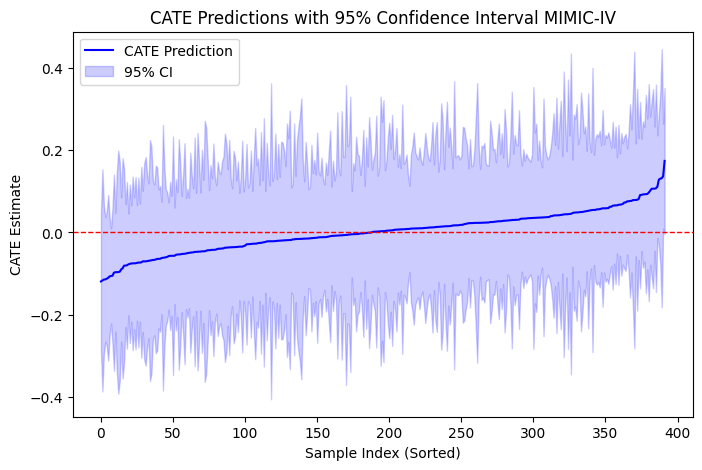

In [122]:
import matplotlib.pyplot as plt
import numpy as np

# Compute CATE prediction intervals
CATE_pred = causal_forest.effect(myNewXTrain)

cate_lower, cate_upper = causal_forest.effect_interval(myNewXTrain, alpha=0.05)

# Ensure arrays are 1D NumPy arrays
CATE_pred = np.array(CATE_pred).flatten()
cate_lower = np.array(cate_lower).flatten()
cate_upper = np.array(cate_upper).flatten()

# Sort values for a cleaner plot
sorted_idx = np.argsort(CATE_pred)
cate_pred_sorted = CATE_pred[sorted_idx]
cate_lower_sorted = cate_lower[sorted_idx]
cate_upper_sorted = cate_upper[sorted_idx]

# Create x-axis index
x = np.arange(len(cate_pred_sorted))

# Plot CATE predictions
plt.figure(figsize=(8, 5))
plt.plot(x, cate_pred_sorted, label='CATE Prediction', color='blue')

# Fill confidence interval
plt.fill_between(x, cate_lower_sorted, cate_upper_sorted, 
                 color='blue', alpha=0.2, label='95% CI')
plt.axhline(0, color='red', linestyle='--', linewidth=1)
# Labels and title
plt.xlabel("Sample Index (Sorted)")
plt.ylabel("CATE Estimate")
plt.title("CATE Predictions with 95% Confidence Interval MIMIC-IV")
plt.legend()
plt.show()


Optimization terminated successfully.
         Current function value: 0.635411
         Iterations 5
Optimization terminated successfully.
         Current function value: 0.634173
         Iterations 5
Likelihood ratio of test results:
Chi square statistic: 1.0520993414195345
p-value: 0.3050240846757174
Degress of freedom: 1.0
No interaction                            Logit Regression Results                           
Dep. Variable:         death_at_disch   No. Observations:                  425
Model:                          Logit   Df Residuals:                      422
Method:                           MLE   Df Model:                            2
Date:                Sun, 27 Apr 2025   Pseudo R-squ.:                0.009975
Time:                        19:48:13   Log-Likelihood:                -270.05
converged:                       True   LL-Null:                       -272.77
Covariance Type:            nonrobust   LLR p-value:                   0.06582
                      

[Parallel(n_jobs=20)]: Using backend ThreadingBackend with 20 concurrent workers.
[Parallel(n_jobs=20)]: Done   1 tasks      | elapsed:    0.0s
[Parallel(n_jobs=20)]: Done 100 out of 100 | elapsed:    0.0s finished


0.3050240846757174

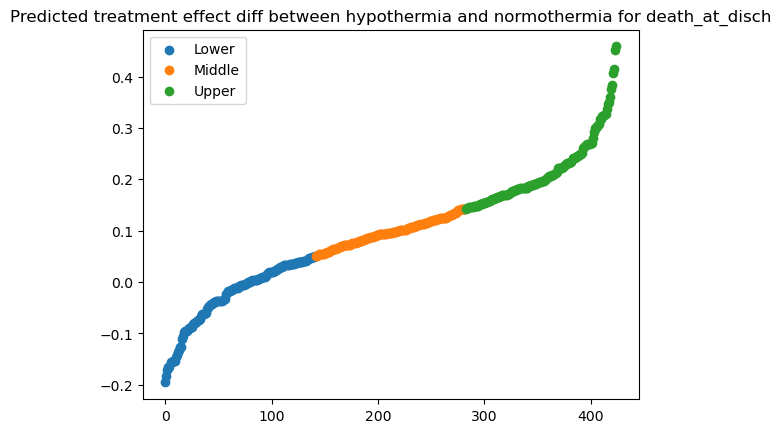

In [30]:
# myNewXTest = myPipeline.transform(X_test_no_group)
CATE_pred = causal_forest.effect(myNewXTest)

myNewDf = pd.DataFrame()
myNewDf['predicted_effect'] = CATE_pred[:, 0]
lower_third, upper_third, _ = getPredictedThirds(myNewDf)
plotPredictedTreatmentEffect(myNewDf, myPredicted)
myNewDf['predicted_effect_group'] = (myNewDf['predicted_effect'] > 0).astype(str)


X_test_new = X_test_no_group.copy().reset_index()
X_test_new[myTreatment] = T_test.reset_index()[myTreatment]
y_test_df = pd.DataFrame()
y_test_df[myPredicted] = y_test.reset_index()[myPredicted]
getTreatmentEffectDiffDataFrame(X_test_new, y_test_df, myNewDf, myPredicted, myTreatment, False)